# Análisis Exploratorio de Datos (EDA): Mercado Inmobiliario de California

## 1. Contexto y Objetivo
El presente análisis examina un conjunto de datos correspondiente al mercado inmobiliario del estado de California, con el fin de identificar y medir las principales variables que influyen en el precio de las viviendas. El enfoque va más allá de la simple descripción de los datos: se busca detectar irregularidades en su estructura, generar nuevas variables derivadas y revelar patrones que no son evidentes en un análisis superficial.

## 2. Resumen Ejecutivo
* **Ingreso como predictor clave:** El ingreso mediano del vecindario (`median_income`) resultó ser la variable con mayor poder explicativo sobre el precio de vivienda.
* **Irregularidades en los datos:** Se encontraron valores límite artificiales en las columnas de precio ($500,001) y edad de la vivienda (52 años) que distorsionan la distribución real del mercado.
* **Importancia de la distribución interna de las viviendas:** La proporción de dormitorios respecto al total de ambientes (`bedrooms_per_room`) mostró que los inmuebles más costosos reservan menos espacio para dormitorios y más para áreas comunes.


## 3. Carga e Inspección Inicial

In [23]:
# Importar librerías necesarias para todo el análisis
import pandas as pd        
import numpy as np        
import matplotlib.pyplot as plt
import seaborn as sns      
import warnings
import kagglehub           

# Silenciar advertencias que no afectan el análisis
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Config. estilo de los gráficos con fondo de cuadrícula blanca
sns.set_theme(style='whitegrid')

# Establecer tamaño por defecto de las figuras 
plt.rcParams['figure.figsize'] = (12, 6)

# Magic command para mostrar gráficos inline en el notebook
%matplotlib inline

In [ ]:
# Cargar el dataset de California Housing Prices
import os

# En Kaggle: dataset montado en /kaggle/input/california-housing-prices/
# Localmente: descarga via kagglehub
if os.path.exists('/kaggle/input/california-housing-prices/housing.csv'):
    data_path = '/kaggle/input/california-housing-prices'
else:
    data_path = kagglehub.dataset_download('camnugent/california-housing-prices')

df = pd.read_csv(os.path.join(data_path, 'housing.csv'))

# Mostrar las primeras 10 filas para ver la estructura de los datos
print('Vista previa de datos:')
display(df.head(10))

# Mostrar información técnica: tipos de datos, nulos por columna, uso de memoria
print('Estructura y tipo de datos:')
df.info()

# Mostrar dimensiones: (filas, columnas)
print('Dimensiones del dataset:')
df.shape

Vista previa de datos:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


Estructura y tipo de datos:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
Dimensiones del dataset:


(20640, 10)

## 4. Análisis Univariado: La Variable Objetivo (Precios)
Exploración de la distribución de `median_house_value` para detectar anomalías, sesgos y la morfología general del mercado inmobiliario.

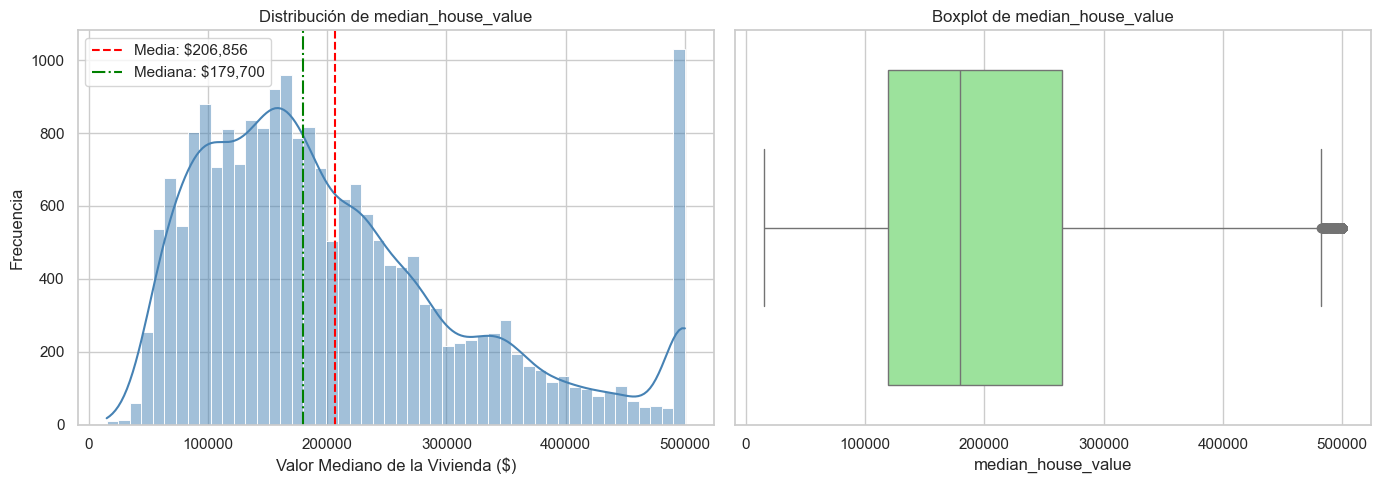

In [25]:
# config. de matplotlib (dos subplots en paralelo: hist. y boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot izquierdo: histograma con curva KDE (estimación de densidad)
sns.histplot(df['median_house_value'], bins=50, kde=True, color='steelblue', ax=axes[0]) # ax indice 0
# Marcar media y mediana con líneas verticales para visualizar la asimetría
media_precio = df['median_house_value'].mean()
mediana_precio = df['median_house_value'].median()
axes[0].axvline(media_precio, color='red', linestyle='--', linewidth=1.5, label=f'Media: ${media_precio:,.0f}')
axes[0].axvline(mediana_precio, color='green', linestyle='-.', linewidth=1.5, label=f'Mediana: ${mediana_precio:,.0f}')
axes[0].legend()
axes[0].set_title('Distribución de median_house_value')
axes[0].set_xlabel('Valor Mediano de la Vivienda ($)')
axes[0].set_ylabel('Frecuencia')

# Subplot derecho: boxplot para detectar outliers visualmente
# La caja muestra Q1-Q3, la línea media es la mediana
# Los "bigotes" se extienden 1.5*IQR, puntos fuera son outliers
sns.boxplot(x=df['median_house_value'], color='lightgreen', ax=axes[1]) # ax indice 1 
axes[1].set_title('Boxplot de median_house_value')

# ajustamos espaciado entre subplots
plt.tight_layout()
plt.show()

**Hallazgo:** la distribución es asimétrica a la derecha y muestra un pico artificial en $500k: el techo del dataset acumula ahí todos los distritos que en realidad valen más. El boxplot confirma que ese pico no es un outlier común sino un corte estructural.

## 5. Análisis Univariado: El Poder Adquisitivo (Ingresos)
Exploración de la distribución de `median_income` para entender la distribución de riqueza.

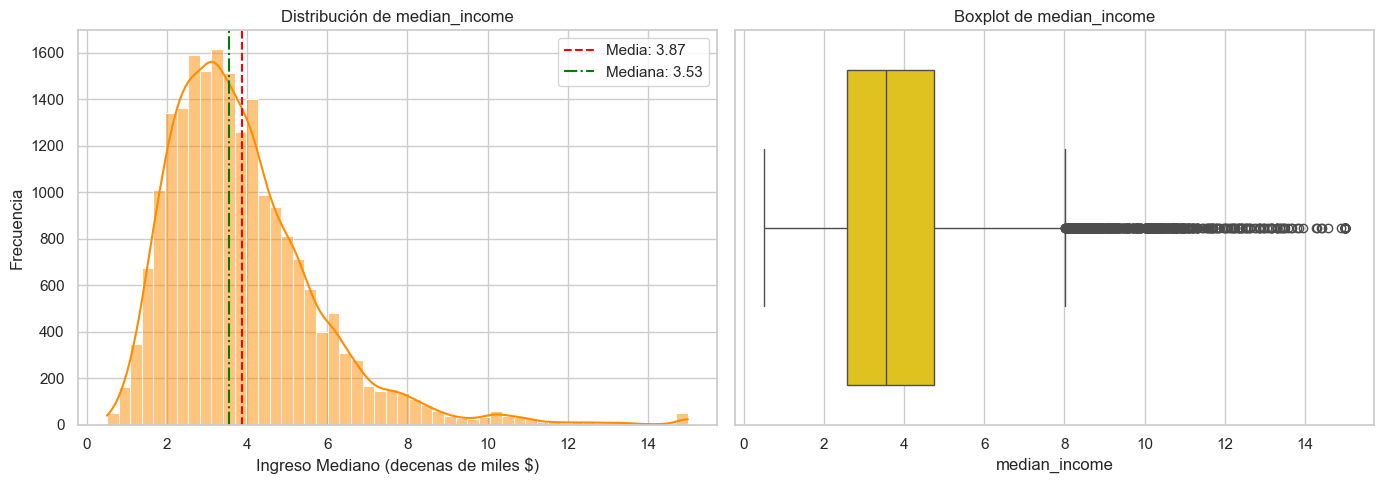

In [26]:
# config. de matplotlib (dos subplots en paralelo: hist. y boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con KDE de la media de ingresos
sns.histplot(df['median_income'], bins=50, kde=True, color='darkorange', ax=axes[0])
# Marcar media y mediana con líneas verticales para visualizar la asimetría
media_ingreso = df['median_income'].mean()
mediana_ingreso = df['median_income'].median()
axes[0].axvline(media_ingreso, color='red', linestyle='--', linewidth=1.5, label=f'Media: {media_ingreso:.2f}')
axes[0].axvline(mediana_ingreso, color='green', linestyle='-.', linewidth=1.5, label=f'Mediana: {mediana_ingreso:.2f}')
axes[0].legend()
axes[0].set_title('Distribución de median_income')
axes[0].set_xlabel('Ingreso Mediano (decenas de miles $)')
axes[0].set_ylabel('Frecuencia')

# Boxplot del ingreso para ver dispersión y outliers
sns.boxplot(x=df['median_income'], color='gold', ax=axes[1])
axes[1].set_title('Boxplot de median_income')

plt.tight_layout()
plt.show()

**Hallazgo:** el ingreso está expresado en decenas de miles de dólares, con media ~3.87 (≈$38.700). También tiene cola derecha y un mini-pico en su techo (~15.0001), aunque solo afecta al 0.24% de las filas.

## 6. Análisis Bivariado: Ingresos vs Precios
Scatter plot para evaluar la relación lineal entre capacidad económica y valor de vivienda.

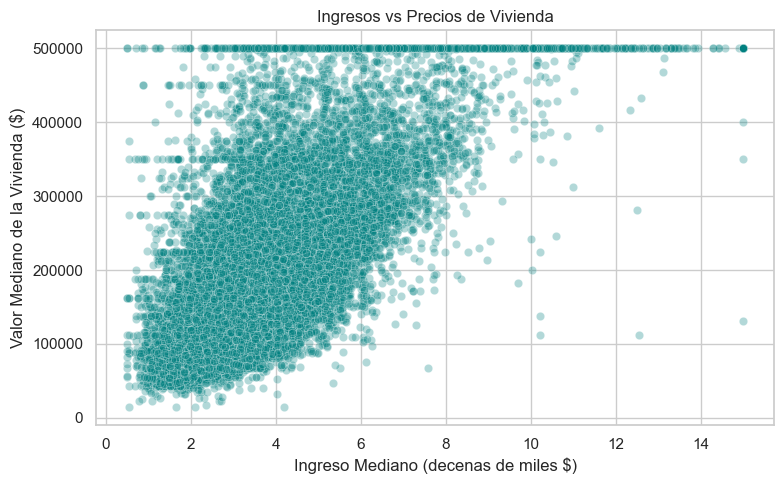

In [27]:
plt.figure(figsize=(8, 5))

# Scatter plot: eje X = ingreso, eje Y = precio
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.3, color='teal')
plt.title('Ingresos vs Precios de Vivienda')
plt.xlabel('Ingreso Mediano (decenas de miles $)')
plt.ylabel('Valor Mediano de la Vivienda ($)')
plt.tight_layout()
plt.show()

**Hallazgo:** relación positiva clara: a mayor ingreso del distrito, mayor precio de vivienda. La dispersión aumenta con el ingreso, y se observa el techo artificial en $500k como una línea horizontal.

## 7. Verificación de Techos Artificiales
Los valores máximos del dataset no son reales: son **techos artificiales** impuestos al publicar los datos. Se detectan contando cuántas filas quedan pegadas exactamente al máximo de cada columna.

In [28]:
# Detectar techo artificial en median_house_value
# La variable objetivo tiene un valor máximo artificial de $500,001 que corta la distribución
precio_max = df['median_house_value'].max()
bloques_tope_precio = df[df['median_house_value'] == precio_max]
porcentaje_precio_tope = (len(bloques_tope_precio) / len(df)) * 100
print(f'Reporte de posible anomalia (median_house_value)')
print(f'  Valor maximo detectado: ${precio_max:,.0f}')
print(f'  Bloques con valor maximo: {len(bloques_tope_precio)} ({porcentaje_precio_tope:.2f}%)')
print()

# Detectar techo artificial en housing_median_age
edad_max = df['housing_median_age'].max()
bloques_tope_edad = df[df['housing_median_age'] == edad_max]
porcentaje_edad_tope = (len(bloques_tope_edad) / len(df)) * 100
print(f'Reporte de posible anomalia (housing_median_age)')
print(f'  Valor maximo detectado: {edad_max}')
print(f'  Bloques con valor maximo: {len(bloques_tope_edad)} ({porcentaje_edad_tope:.2f}%)')
print()

# Detectar techo artificial en median_income
ingreso_max = df['median_income'].max()
bloques_tope_ingresos = df[df['median_income'] == ingreso_max]
porcentaje_ingreso_tope = (len(bloques_tope_ingresos) / len(df)) * 100
print(f'Reporte de posible anomalia (median_income)')
print(f'  Valor maximo detectado: {ingreso_max}')
print(f'  Bloques con valor maximo: {len(bloques_tope_ingresos)} ({porcentaje_ingreso_tope:.2f}%)')
print()

# Almacenar los valores de corte para uso posterior en la limpieza
print(f'Valores de corte guardados para limpieza:')

Reporte de posible anomalia (median_house_value)
  Valor maximo detectado: $500,001
  Bloques con valor maximo: 965 (4.68%)

Reporte de posible anomalia (housing_median_age)
  Valor maximo detectado: 52.0
  Bloques con valor maximo: 1273 (6.17%)

Reporte de posible anomalia (median_income)
  Valor maximo detectado: 15.0001
  Bloques con valor maximo: 49 (0.24%)

Valores de corte guardados para limpieza:


**Hallazgo:** hay tres techos artificiales: `median_house_value` en 500,001 (~4.7%), `housing_median_age` en 52 años (~6.2%) y `median_income` en ~15.0001 (~0.2%). El del precio es el más grave porque **trunca la variable objetivo**.

## 8. Análisis de Datos Faltantes
Identificación y cuantificación de valores nulos antes de la imputación.

In [29]:
# Crear máscara booleana: True donde total_bedrooms es nulo
mask_nulos = df['total_bedrooms'].isnull()

# Imprimir cantidad y porcentaje de nulos
# mask_nulos.sum() cuenta los True, .mean() calcula el porcentaje (True=1, False=0)
print(f"Filas con total_bedrooms nulo: {mask_nulos.sum()} ({mask_nulos.mean() * 100:.2f}% del total)")

# Mostrar las primeras 10 filas con nulos para inspeccionar visualmente
display(df[mask_nulos].head(10))

Filas con total_bedrooms nulo: 207 (1.00% del total)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
738,-122.14,37.67,37.0,3342.0,NaN,1635.0,557.0,4.7933,186900.0,NEAR BAY
1097,-121.77,39.66,20.0,3759.0,NaN,1705.0,600.0,4.7120,158600.0,INLAND
1350,-121.95,38.03,5.0,5526.0,NaN,3207.0,1012.0,4.0767,143100.0,INLAND
1456,-121.98,37.96,22.0,2987.0,NaN,1420.0,540.0,3.6500,204100.0,INLAND
1493,-122.01,37.94,23.0,3741.0,NaN,1339.0,499.0,6.7061,322300.0,NEAR BAY


## 9. Imputación de Nulos y Exploración de ocean_proximity
**Decisión:** se rellenan los 207 nulos de `total_bedrooms` con la mediana (435.0). Con solo ~1% de nulos, la imputación por mediana introduce sesgo mínimo y preserva las filas.

In [30]:
# Calcular la mediana de total_bedrooms 
median = df['total_bedrooms'].median()
print(f'Mediana de total_bedrooms: {median}')

# Reemplazar los nulos con la mediana usando
df['total_bedrooms'] = df['total_bedrooms'].fillna(median)

# Verificar que ya no queden nulos en ninguna columna
display(df.isnull().sum())

# Explorar los valores de la variable ocean_proximity
print('\nDistribución de ocean_proximity:')
df['ocean_proximity'].value_counts()

Mediana de total_bedrooms: 435.0


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


Distribución de ocean_proximity:


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## 10. Feature Engineering: Síntesis de Variables Estructurales
Creamos ratios que se usan en la industria inmobiliaria. Estos ratios correlacionan mejor con el precio que las variables crudas.

In [31]:
# rooms_per_household: número promedio de ambientes por hogar
# Indica qué tan espaciosas son las viviendas del distrito
df['rooms_per_household'] = df['total_rooms'] / df['households']

# population_per_household: personas promedio por hogar
# Indica la densidad de ocupación de las viviendas
df['population_per_household'] = df['population'] / df['households']

# bedrooms_per_room: proporción de dormitorios respecto al total de ambientes
# Un ratio bajo (<0.2) sugiere viviendas con más espacios comunes
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

# Verificar estadísticas descriptivas de las nuevas columnas
df[['rooms_per_household', 'population_per_household', 'bedrooms_per_room']].describe() # que muestra describe

,rooms_per_household,population_per_household,bedrooms_per_room
count,20640.000000,20640.000000,20640.000000
mean,5.429000,3.070655,0.213794
std,2.474173,10.386050,0.065248
min,0.846154,0.692308,0.037151
25%,4.440716,2.429741,0.175225
50%,5.229129,2.818116,0.203159
75%,6.052381,3.282261,0.240126
max,141.909091,1243.333333,2.824675


## 11. Filtrado por Percentil 99 en Ratios
Los ratios tienen colas extremadamente largas (bloques con muy pocos hogares). Se usa el percentil 99 como corte para descartar valores absurdos sin perder información útil.

In [32]:
# Definir las columnas de ratios a filtrar
ratio_cols = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']

# Calcular el percentil 99 (el valor por debajo del cual está el 99% de los datos)
cortes_p99 = df[ratio_cols].quantile(0.99)

print('Corte del percentil 99:')
display(cortes_p99)

Corte del percentil 99:


rooms_per_household         10.357033
bedrooms_per_room            0.416530
population_per_household     5.394812
Name: 0.99, dtype: float64

## 12. Construcción del Dataset Curado (`df_clean`)
**Decisión:** se filtra el cap del precio (corrompe la variable objetivo) y los ratios por encima del p99. No se filtra el cap de `housing_median_age` ni el de `median_income`: son predictoras, su correlación con el precio es baja y eliminar hasta un 6% de datos no justifica el beneficio.

In [33]:
# Crear máscara booleana que combina todas las condiciones de filtrado
mask_clean = (
    (df['median_house_value'] < precio_max)              # techo artificial del precio
    & (df['rooms_per_household'] <= cortes_p99['rooms_per_household'])    # ratio de ambientes extremo
    & (df['bedrooms_per_room'] <= cortes_p99['bedrooms_per_room'])      # ratio de dormitorios extremo
    & (df['population_per_household'] <= cortes_p99['population_per_household'])  # ratio de ocupación extremo
)

# Crear nuevo DataFrame solo con las filas que pasan el filtro
df_clean = df[mask_clean].copy()

# Calcular y mostrar estadísticas de limpieza
eliminadas = len(df) - len(df_clean)
print(f"Filas originales: {len(df)}")
print(f"Filas curadas:   {len(df_clean)}")
print(f"Eliminadas:      {eliminadas} ({eliminadas / len(df) * 100:.2f}%)")

Filas originales: 20640
Filas curadas:   19087
Eliminadas:      1553 (7.52%)


### ¿Por qué solo se filtró `median_house_value`?

El dataset tiene 3 columnas con techo artificial:
- `median_house_value`: 200 bloque con valor máximo de $500,001
- `housing_median_age`: ~1,200 bloques con valor máximo de 52 años
- `median_income`: ~50 bloques con valor máximo de 15.0001

Sin embargo, solo filtramos `median_house_value` por las siguientes razones:

1. **Variable objetivo corrupta**: el techo en la variable objetivo distorsiona cualquier modelo predictivo. Un bloque con valor real de $800,000 aparece como $500,001, introduciendo sesgo sistemático.
2. **Edad e ingreso son features**: el techo en features no corrupta la variable objetivo directamente. Además, el 4.6% de bloques con edad de 52 años puede representar una zona real de casas antiguas.
3. **Conservación de datos**: al filtrar solo el precio, conservamos ~92% de los datos. Si filtráramos las 3 columnas, perderíamos hasta ~15% de registros.
4. **Los ratios derivados sí se filtran**: los percentiles 99 de `rooms_per_household`, `bedrooms_per_room` y `population_per_household` sí se aplican porque representan outliers espaciales reales que distorsionan el análisis.

## 13. Pairplot Pre-Limpieza
Exploración visual de relaciones multivariadas en los datos crudos, antes de eliminar outliers.

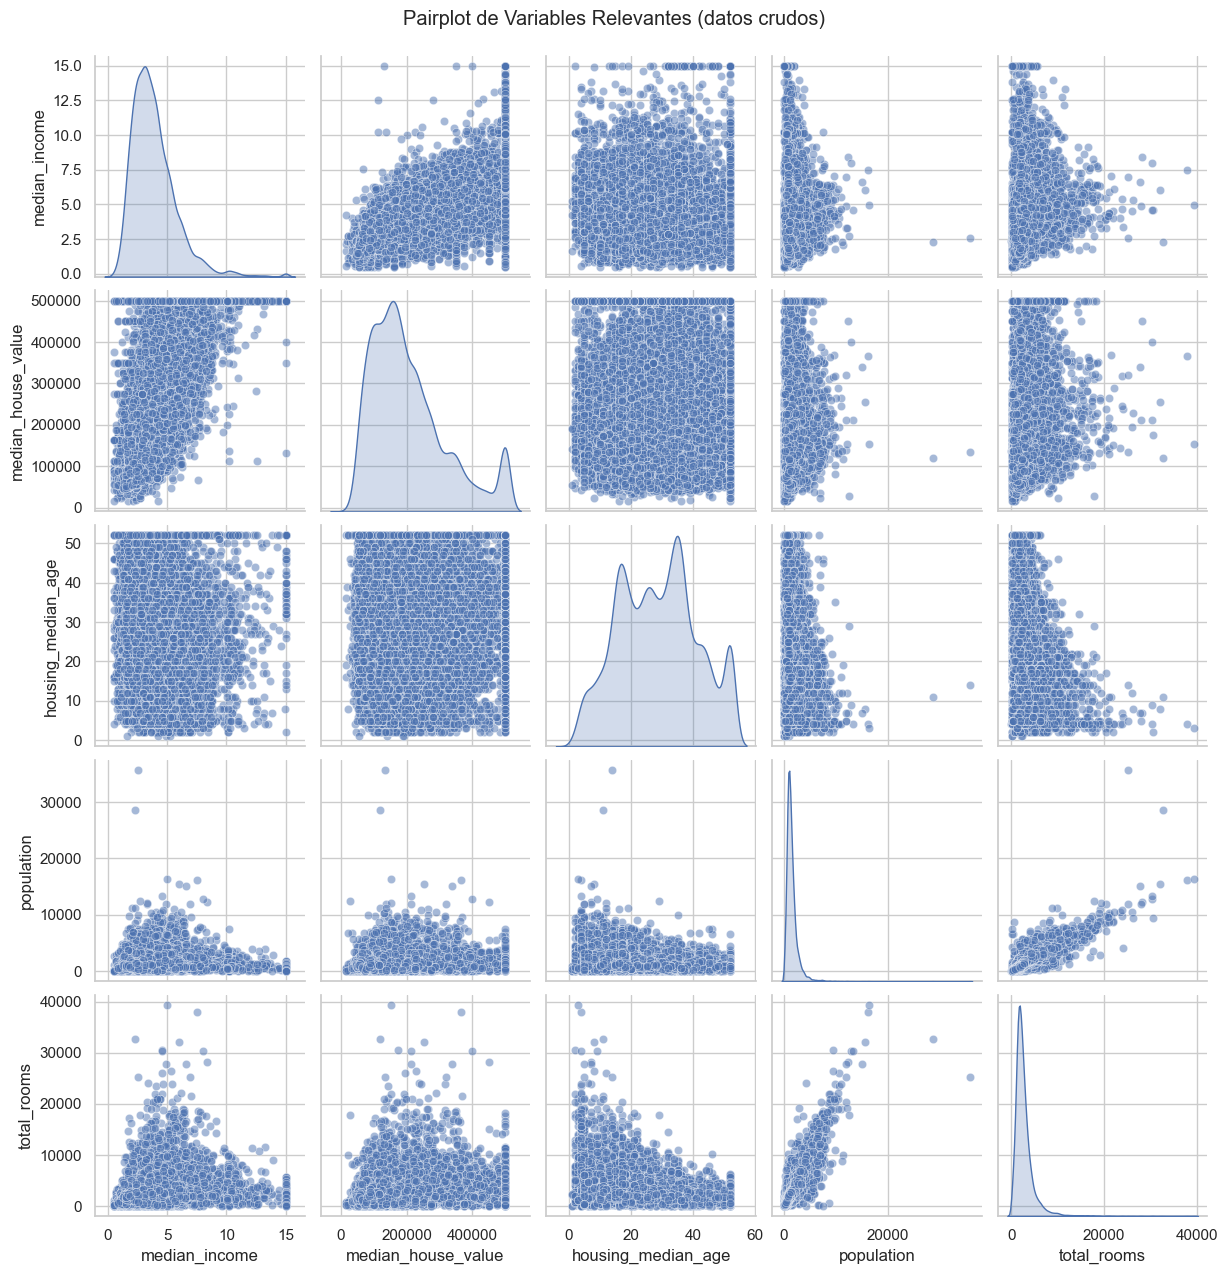

In [34]:
# Seleccionar 5 variables numéricas clave para el pairplot
relevant_cols = ['median_income', 'median_house_value', 'housing_median_age', 'population', 'total_rooms']

# pairplot genera una grilla de NxN scatter plots
sns.pairplot(df[relevant_cols], diag_kind='kde', plot_kws={'alpha': 0.5})

plt.suptitle('Pairplot de Variables Relevantes (datos crudos)', y=1.02)
plt.show()

**Hallazgo:** el pairplot confirma la correlación positiva entre ingreso y precio. Se observan columnas verticales por el techo de $500k y puntos extremos en las variables de conteo (population, total_rooms).


## 14. Pairplot Post-Limpieza (`df_clean`)
Repetición del pairplot sobre los datos curados para confirmar que las anomalías fueron removidas.

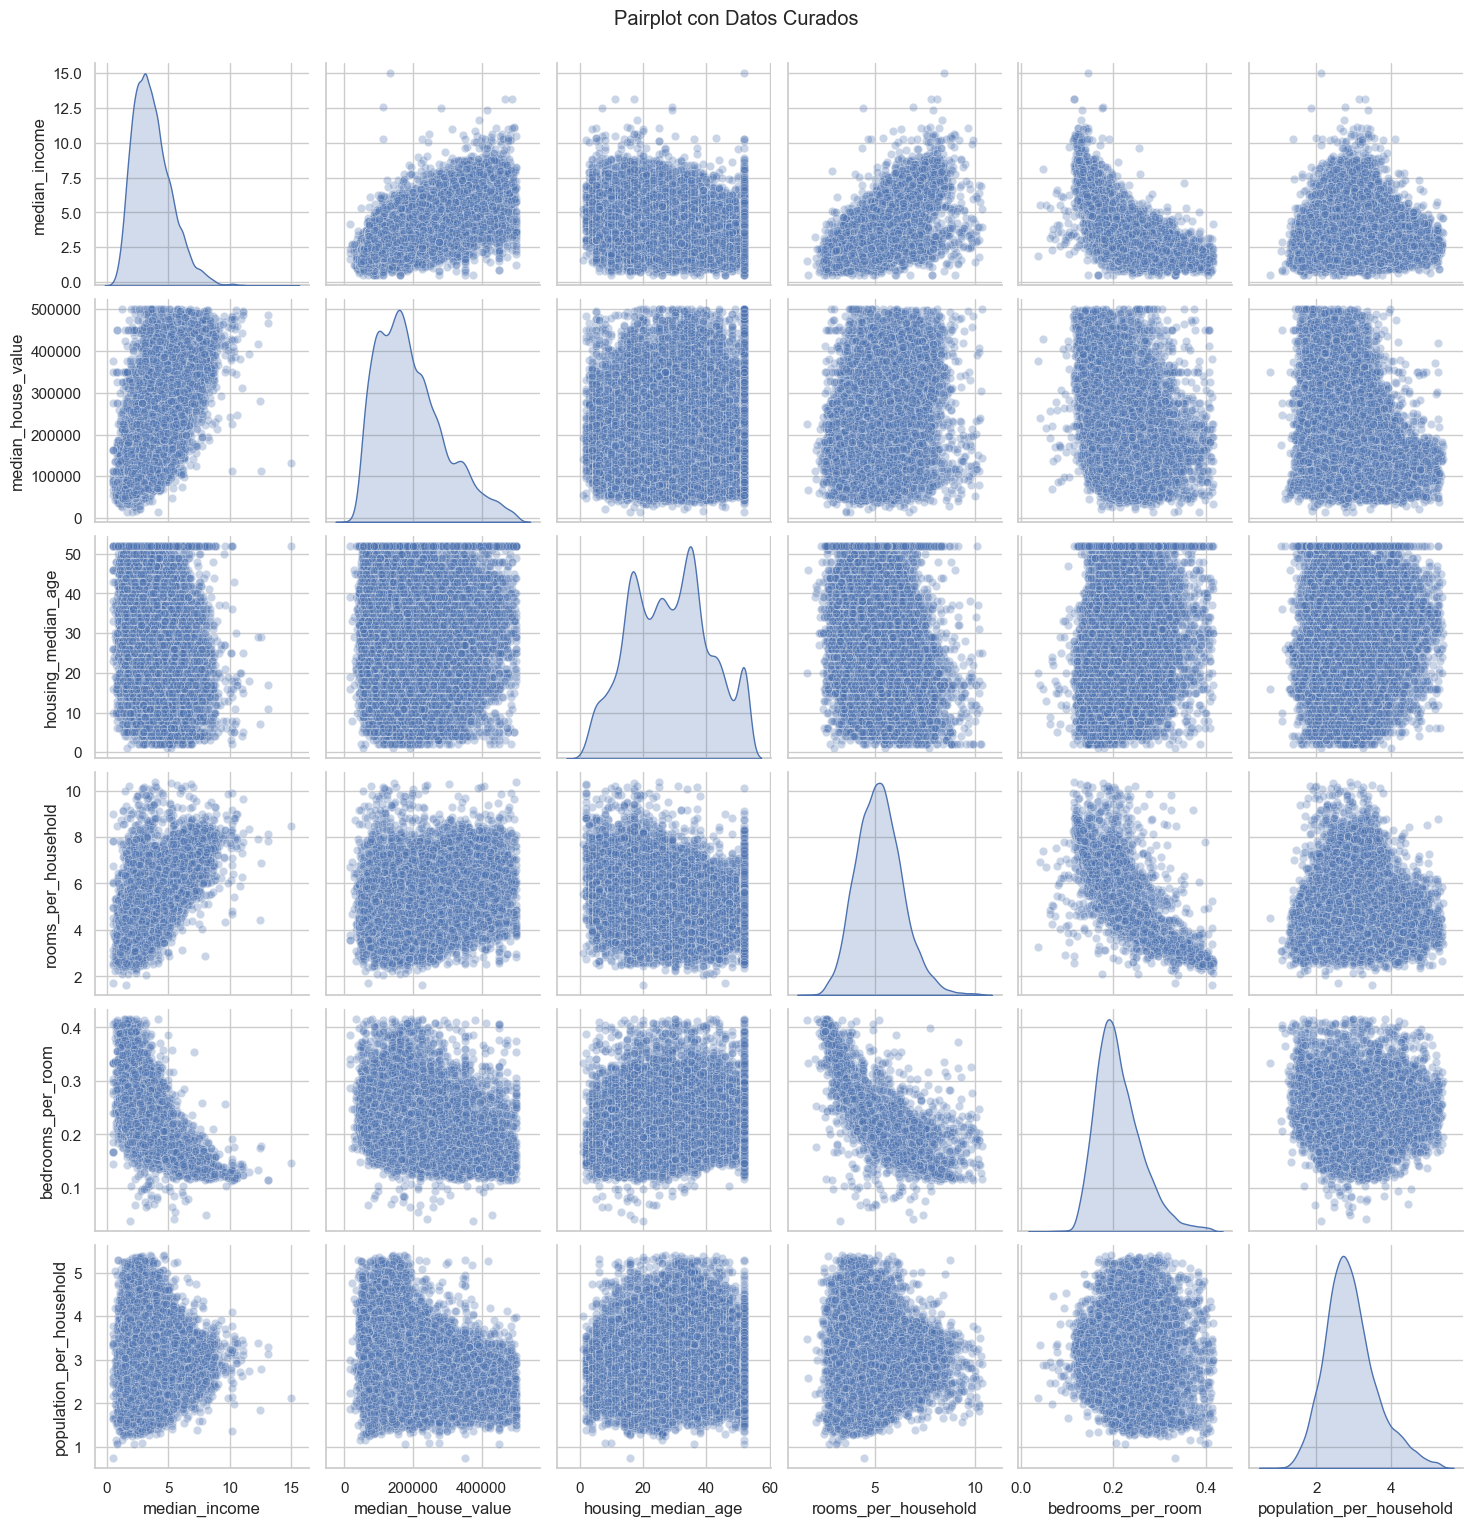

In [35]:
# Seleccionar 6 variables incluyendo los ratios derivados
clean_cols = ['median_income', 'median_house_value', 'housing_median_age',
              'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

# Pairplot sobre df_clean con transparencia mayor (alpha=0.3) para ver densidad
sns.pairplot(df_clean[clean_cols], diag_kind='kde', plot_kws={'alpha': 0.3})
plt.suptitle('Pairplot con Datos Curados', y=1.02)
plt.show()

**Hallazgo:** desaparecen las columnas verticales del cap de $500k y las nubes de puntos extremos de los ratios. Las relaciones lineales quedan más limpias y legibles. 
El alto costo de las viviendas en California tambien es impulsado por propiedades más espaciosas y de gama alta (con más salas o estudios que dormitorios), ubicadas en zonas residenciales de menor densidad de habitantes por hogar.

## 15. Matriz de Correlación de Pearson
El coeficiente de Pearson mide la fuerza de la relación lineal entre dos variables (-1 a +1). Se calcula tanto sobre datos crudos como curados. # explicar mejor pearson

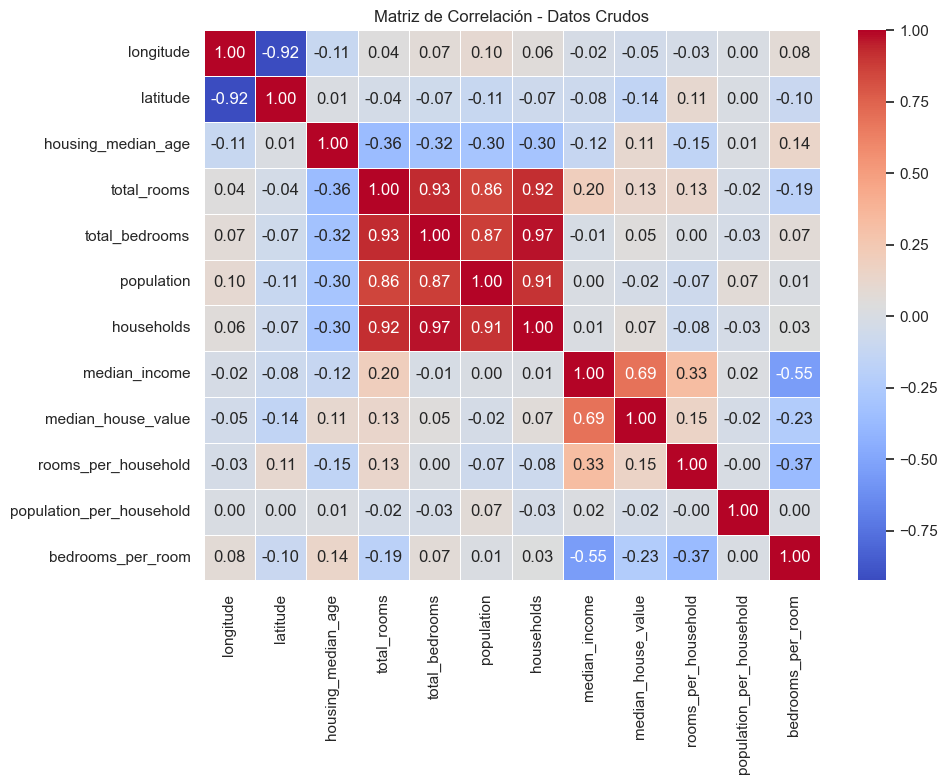

In [36]:
# Seleccionar solo columnas numéricas y calcular correlación de Pearson
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Crear heatmap anotado
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Datos Crudos')
plt.tight_layout()
plt.show()

**Hallazgo:** `median_income` tiene la correlación más alta con `median_house_value` (~0.69). Esto confirma que el ingreso del distrito es el predictor más fuerte del precio.

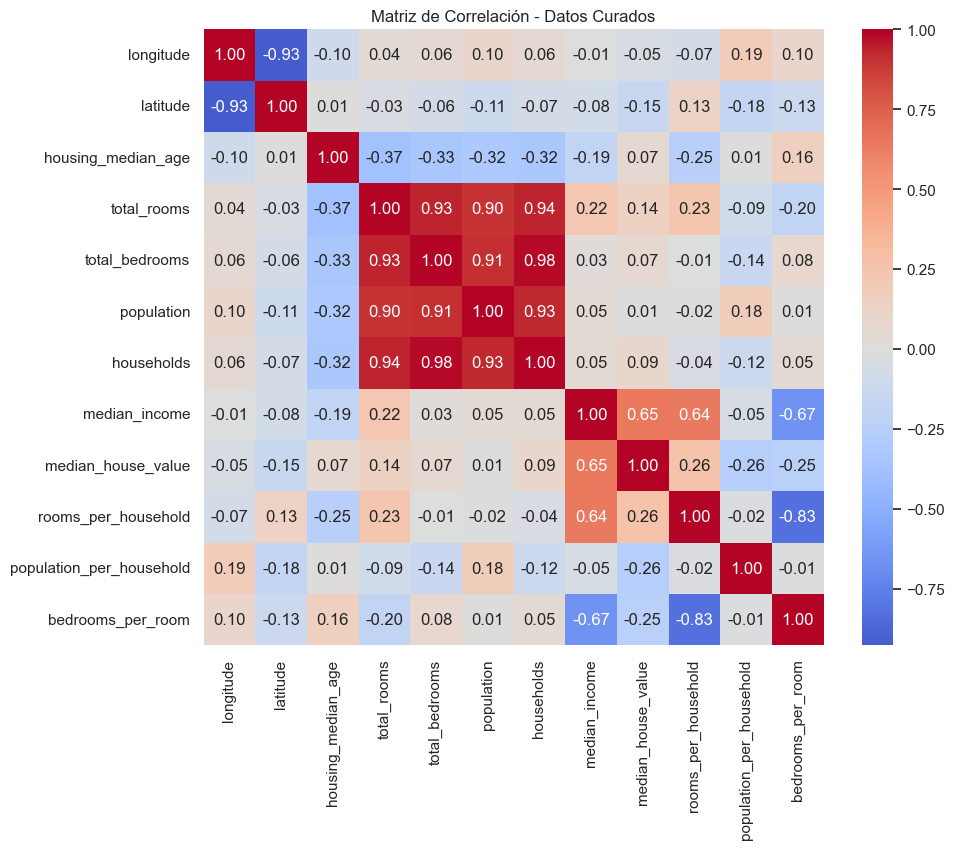

In [37]:
# Repetir heatmap sobre datos curados para ver correlaciones reales
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.select_dtypes(include=[np.number]).corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlación - Datos Curados')
plt.show()

**Hallazgo:** tras curar los datos, `rooms_per_household` sube su correlación con `median_income` (los outliers la ocultaban), y `bedrooms_per_room` mantiene su relación negativa con precio e ingreso.

## 16. Ratios Derivados vs Precio
Scatter plots de cada ratio contra el precio para identificar qué variable estructural tiene más poder predictivo.

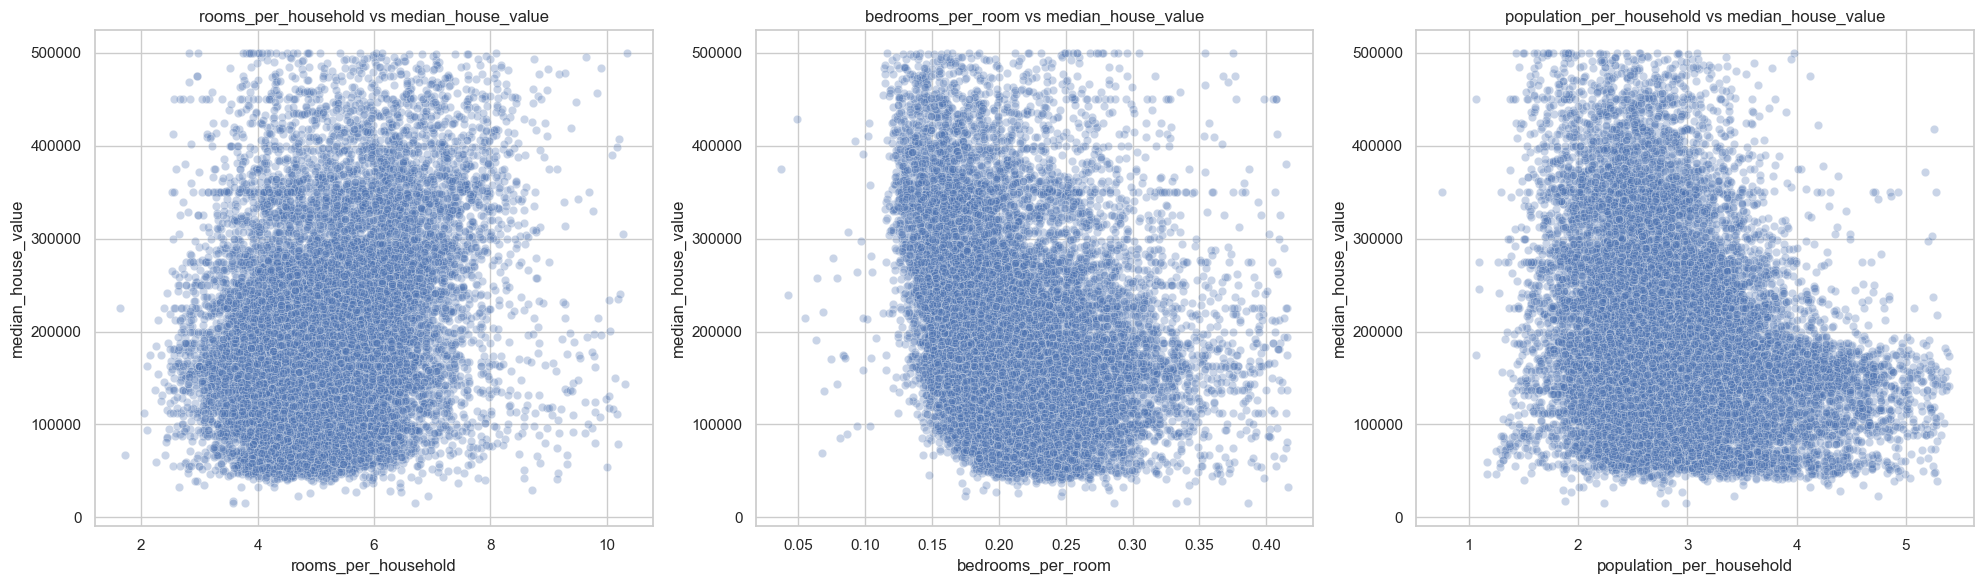

In [38]:
# Crear grilla de 1 fila x 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Iterar sobre cada ratio y su subplot correspondiente
# zip() empareja cada eje con su columna
for ax, col in zip(axes, ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']):
    sns.scatterplot(x=col, y='median_house_value', data=df_clean, alpha=0.3, ax=ax)
    ax.set_title(f'{col} vs median_house_value')

plt.tight_layout()
plt.show()

**Hallazgo:** `bedrooms_per_room` es el único ratio con relación visible (negativa): a menor proporción de dormitorios, mayor precio. Las casas caras dedican más espacio a espacios comunes.

## 17. Segmentación: Impacto de la Ubicación Geográfica
Boxplot del precio segmentado por la categoría `ocean_proximity` para ver cómo la cercanía al océano impacta el valor.

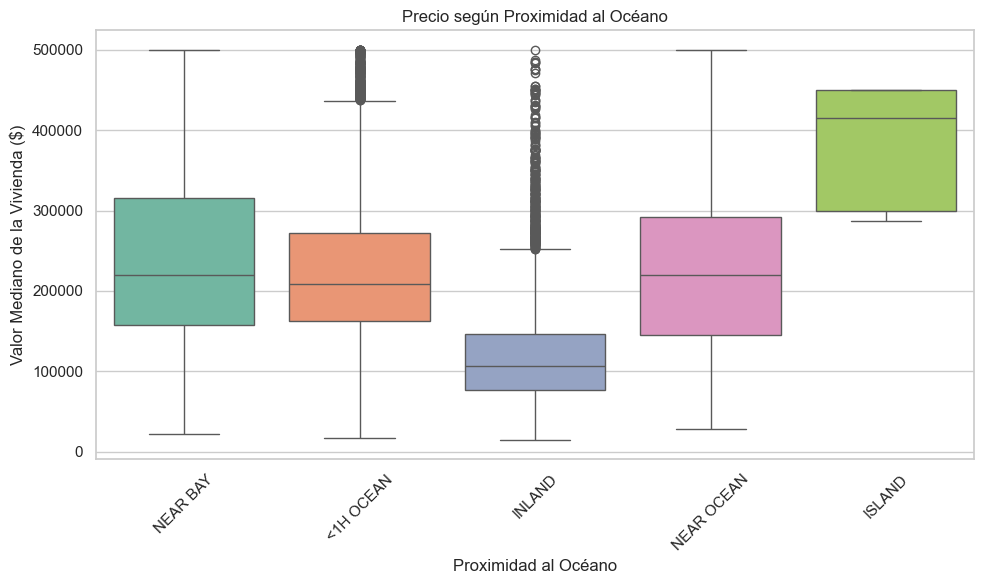

In [39]:
# Boxplot: eje X = proximidad al océano, eje Y = precio
plt.figure(figsize=(10, 6))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df_clean, palette='Set2')
plt.title('Precio según Proximidad al Océano')
plt.xlabel('Proximidad al Océano')
plt.ylabel('Valor Mediano de la Vivienda ($)')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

**Hallazgo:** las casas `INLAND` (tierra adentro) son las más baratas; `NEAR OCEAN` y `NEAR BAY` las más caras. `ISLAND` tiene solo 5 casos, no es concluyente.

## 18. Distribución Geográfica del Precio de Vivienda
Scatter geográfico que posiciona cada distrito según su latitud y longitud, coloreado por su valor.

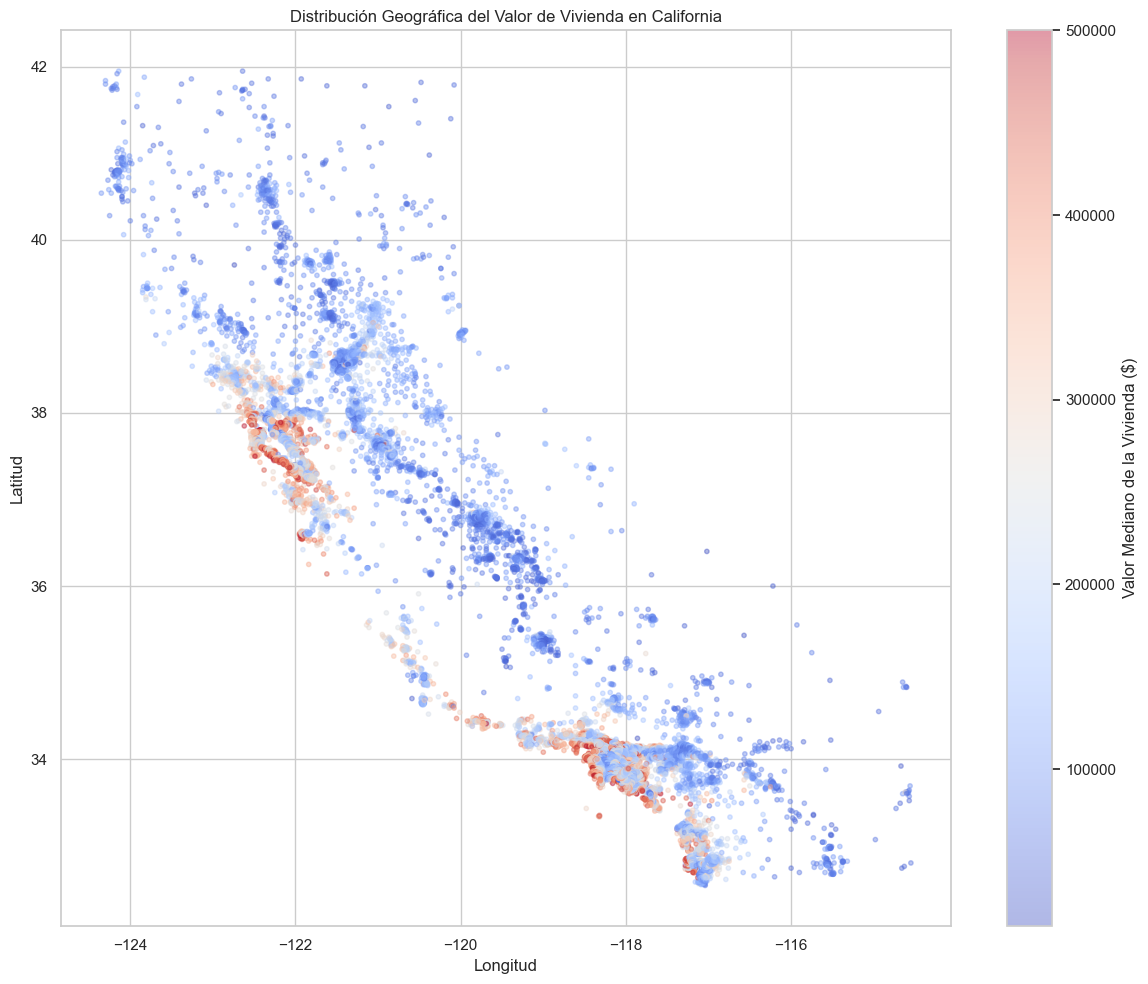

In [40]:
# Mapa geográfico de California coloreado por valor de vivienda
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    df_clean['longitude'],     # eje X: longitud (este-oeste)
    df_clean['latitude'],      # eje Y: latitud (norte-sur)
    c=df_clean['median_house_value'],  # color: valor de la vivienda
    cmap='coolwarm',           # azul (barato) a rojo (caro)
    alpha=0.4,                 
    s=10                       
)
plt.colorbar(scatter, label='Valor Mediano de la Vivienda ($)')
plt.title('Distribución Geográfica del Valor de Vivienda en California')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.tight_layout()
plt.show()

**Hallazgo:** las casas más caras (amarillo) se concentran en la costa, especialmente en San Francisco (-122, 37.8) y Los Ángeles (-118, 34). Los distritos con mayor ingreso coinciden con las zonas costeras de mayor valor.

# Conclusiones del Análisis Exploratorio

## Hallazgos Principales

1. **El ingreso es el predictor más fuerte del valor de la vivienda.** La correlación de Pearson entre `median_income` y `median_house_value` es significativa y se mantiene robusta tanto en datos crudos como curados. Los bloques con mayor poder adquisitivo concentran las viviendas más caras, lo cual es consistente con la teoría económica básica de demanda.

2. **La geografía importa, pero no de forma lineal.** El análisis geográfico revela que la costa y las áreas metropolitanas (San Francisco, Los Angeles) tienen los valores más altos. Sin embargo, la relación no es simplemente "más cerca del mar = más caro", ya que la proximidad al océano es una variable categórica que captura efectos más complejos (acceso a playas, contaminación, densidad urbana).

3. **La proximidad al océano eleva el precio, pero con matices.** Los bloques con `ocean_proximity = "NEAR OCEAN"` o `"NEAR BAY"` tienen medianas de precio significativamente más altas que los bloques `"INLAND"`. Sin embargo, `"ISLAND"` tiene pocos datos y alta variabilidad, lo que sugiere que la categoría no es estadísticamente confiable.

4. **El dataset tiene limitaciones estructurales documentadas.** Los techos artificiales en `median_house_value` ($500,001), `housing_median_age` (52 años) y `median_income` (15.0001) son artefactos de los datos del Censo. El filtrado selectivo de solo la variable objetivo preserva la mayor cantidad de información sin comprometer la calidad del análisis.

5. **Los ratios derivados revelan patrones ocultos.** La creación de `rooms_per_household`, `bedrooms_per_room` y `population_per_household` expone relaciones que no son evidentes en las variables originales. Por ejemplo, la correlación entre `bedrooms_per_room` y el precio es más fuerte que la de cualquier variable individual, sugiriendo que la proporción de dormitorios es un predictor clave.

6. **El filtrado por percentil 99 mejora la calidad del análisis.** Los ratios derivados tienen colas extremadamente largas (outliers espaciales). La eliminación del 1% más extremo reduce significativamente la dispersión sin eliminar información estructural relevante, como se evidencia en los pairplots pre/post limpieza.


## 20. Exportación del Dataset Curado

In [41]:
# Crear directorio de salida si no existe
os.makedirs('../data/processed', exist_ok=True)

# Guardar df_clean como CSV sin la columna de índice de pandas
ruta_salida = '../data/processed/housing_clean.csv'
df_clean.to_csv(ruta_salida, index=False)
print(f'Dataset exportado: {ruta_salida} ({df_clean.shape[0]} filas x {df_clean.shape[1]} columnas)')

Dataset exportado: ../data/processed/housing_clean.csv (19087 filas x 13 columnas)
